# Synthetic Data Augmentation

Now that a small library has been created for generating the CW audio tones, we're closer to beginning training a model on sample data.

If a model were trained on this "perfect" data that has no variance, noise floor, or interference, it'd fail in a real test.

## Synthetic Data Augmentation

Somehow, my perfect synthetic data needs to be modified to have some variance in it.

- Randomize the speed of sending (WPM)
    > Recommended between 10 and 40 WPM.

- Human timing variance
    > "Introduce normal distribuitions of variances to the dits, dashes, and spacing"

- Pitch drift
    > "Transmitters are seldom perfectly stable."

- Atmospheric noise

- Interference
    > Superimpose a second, weaker CW signal at a slightly different CW frequency (100Hz offset)

- Fading
    > Apply Rayleigh fading to the signal amplitude to simulate ionospheric propagation changes.

# Randomizing Sending Speed

For model training, this is a bit confusing. My intuition said that if the samples are between 10 and 40 WPM, we'd expect to see a normal distribution among a bunch of random samples. This is true, however, at the edges of such a distribution, there'll be less and less samples for the model to learn on. So, it's better to have the "macro-distribution" of samples conform to a uniform distribution and "micro-distributions" within the tracks conform to the normal distribution.

Now, some code to set this up:

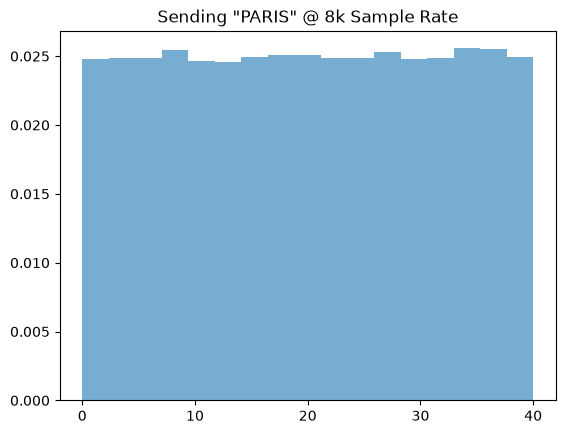

In [1]:
# Normal distribution for overall file WPM:
import numpy as np
import matplotlib.pyplot as plt

macro_wpms = np.random.uniform(low=0, high=40, size = 100000)


plt.title("Sending \"PARIS\" @ 8k Sample Rate")
plt.hist(macro_wpms, bins=17, density=True, alpha=0.6)
plt.style.use("fivethirtyeight")
plt.show()


> Sturge's rule for bins: <br/>
> $k$ = {# bins} <br/>
> $n$ = {# observations} <br/>
> $$k = 1 + log_2(n)$$

```python
if apply_timing_jitter:
        # Apply human-like timing variations
        boundaries = []
        for i in range(len(key_sequence) + 1):
            base_boundary = i * samples_per_tau
            # Add normal distribution jitter (±jitter_std of base tau)
            jitter = np.random.normal(0, jitter_std * samples_per_tau)
            jittered_boundary = base_boundary + jitter
            boundaries.append(jittered_boundary)
        boundaries = np.round(boundaries).astype(int)
    else:
        boundaries = np.round(np.arange(len(key_sequence) + 1) * samples_per_tau).astype(int)
```

A small modification was made to `methods._ook_sr_convert` to account for the micro-variations.

# Testing New Code

## Example 1 - Timing Variance

This variance is added via a flag in `_ook_sr_convert`

In [15]:
import sys
from pathlib import Path

text = "paris"
filename = "paris_with_jitter.wav"
sample_rate = 8000
f_c = 700
jitter = 0.5

# Add project root directory to sys.path
root_dir = Path.cwd().parent
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

from cw import methods as cwm

raw_ook_sn = cwm._word_to_ook_tau(text)

# This introduces the jitter:
m_t_jitter = cwm._ook_sr_convert(raw_ook_sn, 
    wpm = 10, 
    sample_rate=sample_rate, 
    apply_timing_jitter=True, 
    jitter_std=jitter)

# Signal mixed with the 700Hz carrier
ct_mt = cwm._mix_m_t(m_t_jitter, 
    frequency=f_c, 
    sample_rate=sample_rate)

# Now, apply the 1p-lpf filter:
raw_audio = cwm._one_pole_lowpass(ct_mt,
    carrier_frequency=f_c,
    sample_rate=sample_rate)

from cw.signal import write_wav

write_wav(raw_audio, sample_rate=sample_rate, path = filename)

## Example 2 - Pitch drift

In [20]:
text = "paris"
filename = "paris_with_pitch_drift.wav"
sample_rate = 8000
f_c = 700

# Add project root directory to sys.path
root_dir = Path.cwd().parent
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

from cw import methods as cwm

raw_ook_sn = cwm._word_to_ook_tau(text)

m_t_jitter = cwm._ook_sr_convert(raw_ook_sn, 
    wpm = 10, 
    sample_rate=sample_rate, 
    apply_timing_jitter=False)

# Signal mixed with the 700Hz carrier AND DRIFT
ct_mt = cwm._mix_m_t(m_t_jitter, 
    frequency=f_c, 
    sample_rate=sample_rate,
    drift = 1000.0)

# Now, apply the 1p-lpf filter:
raw_audio = cwm._one_pole_lowpass(ct_mt,
    carrier_frequency=f_c,
    sample_rate=sample_rate)

from cw.signal import write_wav

write_wav(raw_audio, sample_rate=sample_rate, path = filename)

# Example 3: Rayleigh Fading



In [28]:
from cw import signal

audio = signal.generate_audio("paris")
audio = cwm._apply_rayleigh_fading(audio, fading_factor = 0.6)
cwm._save_wav(audio, path="paris_with_fading.wav")


# Example 4: Apply QRN (atmospheric noise)

In [38]:
from cw import signal

audio = signal.generate_audio("paris")
audio = cwm._add_atmospheric_noise(audio, noise_level = 0.5)
cwm._save_wav(audio, path="paris_with_qrn.wav")